# ShopTrail: E-commerce Funnel & Customer Behaviour Analysis

Tracing every shopper's path through the Google Merchandise Store, from first visit to purchase.

## 1. Business problem

**Where are customers dropping out of the purchase journey, which channels and segments bring the most value, and which three problems should the business investigate first?**

The work is split in two. BigQuery SQL (`sql/`) builds the clean tables and runs the heavy aggregation. This notebook reads the small result tables saved in `data/processed/`, so it runs without a Google Cloud account. Every chart title states the finding, and each chart is followed by a short interpretation.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

DATA = Path("..") / "data" / "processed"
if not DATA.exists():
    DATA = Path("data") / "processed"

sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
BLUE, ORANGE, GREY, RED = "#2b6cb0", "#dd6b20", "#a0aec0", "#c53030"


def load(name):
    return pd.read_csv(DATA / name)


def thousands(ax, axis="x"):
    fmt = mtick.FuncFormatter(lambda v, _: f"{v:,.0f}")
    (ax.xaxis if axis == "x" else ax.yaxis).set_major_formatter(fmt)


def light_grid(ax, axis):
    """Faint gridlines on the value axis only (x for horizontal bars, y for columns and lines)."""
    ax.grid(True, axis=axis, color="#e2e8f0", linewidth=0.8)
    ax.set_axisbelow(True)

## 2. Data understanding

The data is Google's public GA4 sample of the Google Merchandise Store (`bigquery-public-data.ga4_obfuscated_sample_ecommerce`), one table per day from 1 Nov 2020 to 31 Jan 2021. It includes Black Friday and the December holidays.

In [2]:
overview = load("01_dq_overview.csv").iloc[0]
summary = pd.DataFrame({
    "Measure": ["Events", "Daily tables", "First date", "Last date", "Users (user_pseudo_id)", "Sessions"],
    "Value": [
        f"{overview.total_events:,.0f}",
        f"{overview.daily_tables:.0f}",
        overview.first_date,
        overview.last_date,
        f"{overview.users:,.0f}",
        f"{overview.sessions_with_id:,.0f}",
    ],
})
summary

,Measure,Value
0,Events,"4,295,584"
1,Daily tables,92
2,First date,2020-11-01
3,Last date,2021-01-31
4,Users (user_pseudo_id),"270,154"
5,Sessions,"360,129"


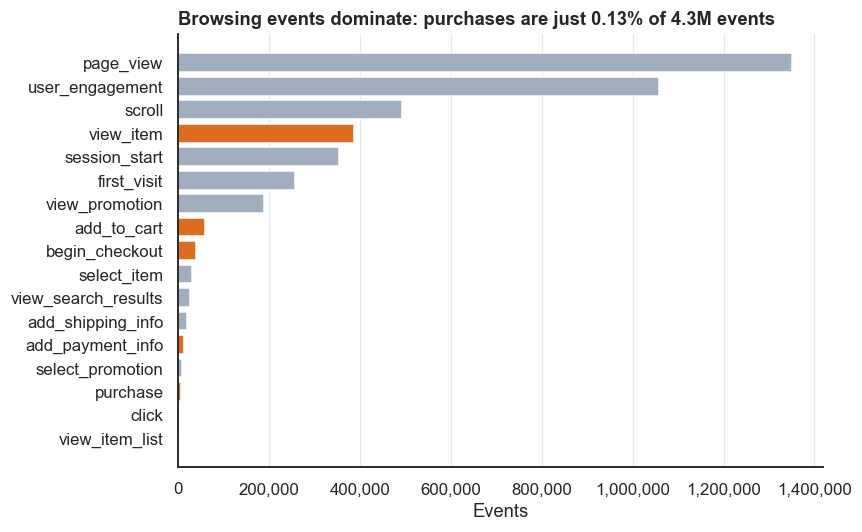

In [3]:
events = load("01_dq_events_by_name.csv")
fig, ax = plt.subplots(figsize=(8, 5))
colors = [ORANGE if e in {"view_item", "add_to_cart", "begin_checkout", "add_payment_info", "purchase"} else GREY for e in events.event_name]
ax.barh(events.event_name[::-1], events.events[::-1], color=colors[::-1])
thousands(ax)
light_grid(ax, "x")
ax.set_xlabel("Events")
ax.set_title("Browsing events dominate: purchases are just 0.13% of 4.3M events")
plt.tight_layout()
plt.show()

Page views, engagement and scroll events make up about two thirds of all traffic, while the funnel events (orange) are a small slice. Purchases are 5,692 raw events, which later shrinks after removing repeats and empty records.

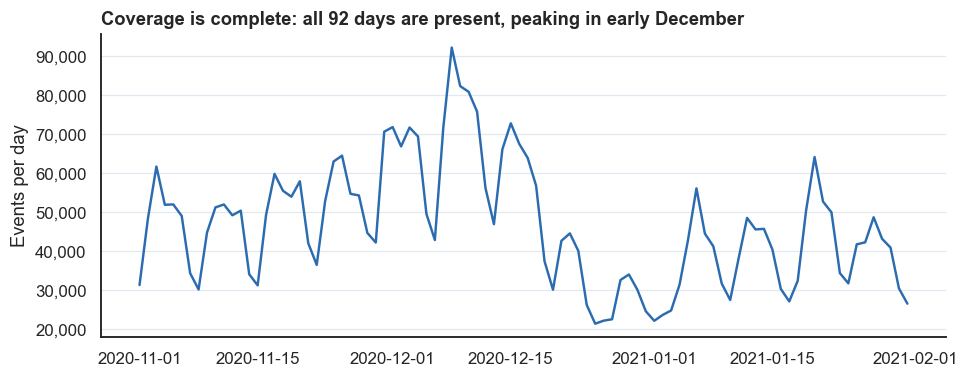

In [4]:
daily = load("01_dq_daily_events.csv")
daily["event_date"] = pd.to_datetime(daily["event_date"])
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(daily.event_date, daily.events, color=BLUE, lw=1.6)
thousands(ax, "y")
light_grid(ax, "y")
ax.set_ylabel("Events per day")
ax.set_title("Coverage is complete: all 92 days are present, peaking in early December")
plt.tight_layout()
plt.show()

There are no missing days. Traffic peaks in the first half of December and drops to its lowest points on 25 December and 1 January, so any holiday comparison has to be made against the early-November baseline and never year over year (there is no prior-year data).

## 3. Data quality

Google deliberately hides some values as `(data deleted)`, `<Other>` or nulls. They are reported here rather than silently dropped, and each analysis says how it handles them.

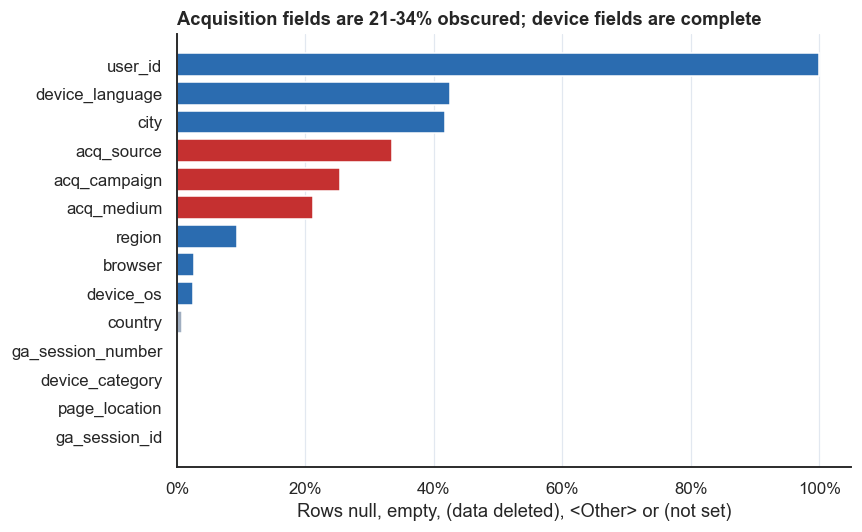

In [5]:
obs = load("01_dq_obscured_values.csv").sort_values("unusable_pct", ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
colors = [RED if c.startswith("acq_") else (GREY if p < 1 else BLUE) for c, p in zip(obs.column_name, obs.unusable_pct)]
ax.barh(obs.column_name, obs.unusable_pct, color=colors)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
light_grid(ax, "x")
ax.set_xlabel("Rows null, empty, (data deleted), <Other> or (not set)")
ax.set_title("Acquisition fields are 21-34% obscured; device fields are complete")
plt.tight_layout()
plt.show()

`user_id` is 100% null, so every user count uses `user_pseudo_id`. The acquisition fields (red) are the weak spot: 33.5% of events have an obscured source and 21.2% an obscured medium, so the channel analysis gets its own rows for obscured values. Country is only 0.75% `(not set)` but city is 41.8%, so city is not used. `device_category`, `ga_session_id` and `ga_session_number` are never missing, which makes the device and session logic reliable.

In [6]:
purchases = load("01_dq_purchases.csv").iloc[0]
sessions_checks = load("02_sessions_checks.csv").iloc[0]
clean = pd.DataFrame({
    "": ["Raw purchase events", "Clean orders"],
    "Count": [f"{purchases.purchase_events:,.0f}", f"{sessions_checks.orders:,.0f}"],
    "Revenue (USD)": [f"${purchases.total_revenue_usd:,.0f}", f"${sessions_checks.revenue_usd:,.0f}"],
})
clean

,,Count,Revenue (USD)
0,Raw purchase events,"5,692","$362,165"
1,Clean orders,"4,907","$339,457"


Raw purchase events overstate orders. Some transactions are logged more than once (326 transaction ids repeat, 335 extra events), and 883 purchase events have no usable transaction id, 450 of them with $0 revenue. An order is therefore one distinct real `transaction_id` (earliest event), plus id-less purchases that carry revenue. That gives **4,907 orders and $339,457**, about 6% less revenue than the raw events suggest.

In [7]:
start = load("01_dq_new_vs_returning_at_start.csv").iloc[0]
print(f"{start.returning_at_first_sight:,.0f} of {start.users:,.0f} users ({start.returning_at_first_sight_pct:.1f}%) already look 'returning' the first time they appear.")

9,006 of 270,154 users (3.3%) already look 'returning' the first time they appear.


Because the data starts on 1 Nov 2020, users who visited earlier look new. The session-number parameter fixes this: a user is **new** only if their lowest `ga_session_number` is 1 (261,148 users) and **returning** otherwise (9,006 users, 3.3%).

## 4. Funnel analysis

**Question:** which stage loses the largest share of potential customers?

The main funnel counts **users** and is **open**: a stage counts everyone who reached it, even if an earlier event was never recorded. A session-level version and a strict-sequence check are shown alongside. `add_shipping_info` is a diagnostic step, not one of the plan's seven stages.

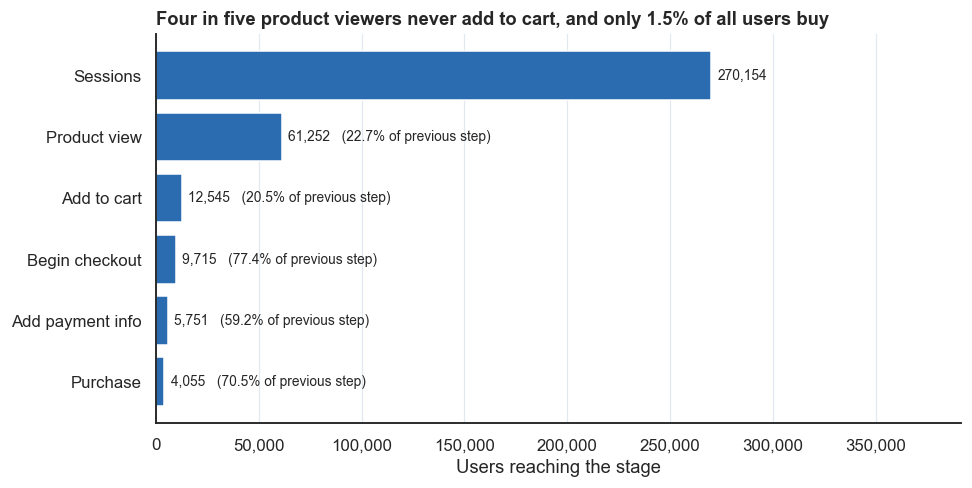

In [8]:
steps = load("04_funnel_steps.csv")
main = steps[~steps.is_diagnostic].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(len(main))[::-1]
ax.barh(y, main.users, color=BLUE)
for yi, row in zip(y, main.itertuples()):
    label = f"{row.users:,.0f}"
    if not np.isnan(row.users_step_conversion_pct) and row.stage_order > 1:
        label += f"   ({row.users_step_conversion_pct:.1f}% of previous step)"
    ax.text(row.users + 3000, yi, label, va="center", fontsize=9)
ax.set_yticks(y)
ax.set_yticklabels(main.stage)
thousands(ax)
light_grid(ax, "x")
ax.set_xlim(0, main.users.max() * 1.45)
ax.set_xlabel("Users reaching the stage")
ax.set_title("Four in five product viewers never add to cart, and only 1.5% of all users buy")
plt.tight_layout()
plt.show()

Of 270,154 users, 61,252 (22.7%) view a product, but only 20.5% of those add something to the cart. That step has the largest relative loss in the main funnel (79.5%), just ahead of the 77.3% who never view a product at all. Overall, 4,055 users buy: **1.50% of all users and 6.6% of product viewers**.

In [9]:
show = steps[["stage", "users", "users_step_conversion_pct", "users_overall_conversion_pct", "users_drop_off", "users_drop_off_pct", "sessions", "sessions_step_conversion_pct"]].copy()
show.columns = ["Stage", "Users", "Step conv. %", "Overall conv. %", "Users lost", "Relative drop-off %", "Sessions", "Sessions step conv. %"]
show.style.format({"Users": "{:,.0f}", "Sessions": "{:,.0f}", "Users lost": "{:,.0f}"}, na_rep="").hide(axis="index")

Stage,Users,Step conv. %,Overall conv. %,Users lost,Relative drop-off %,Sessions,Sessions step conv. %
Sessions,"270,154",,100.000000,,,"360,129",
Product view,"61,252",22.670000,22.670000,"208,902",77.330000,"77,020",21.390000
Add to cart,"12,545",20.480000,4.640000,"48,707",79.520000,"15,188",19.720000
Begin checkout,"9,715",77.440000,3.600000,"2,830",22.560000,"11,106",73.120000
Add shipping info (diagnostic),"9,714",99.990000,3.600000,1,0.010000,"11,105",99.990000
Add payment info,"5,751",59.200000,2.130000,"3,964",40.800000,"6,815",61.360000
Purchase,"4,055",70.510000,1.500000,"1,696",29.490000,"4,435",65.080000


The session-level funnel tells the same story with slightly lower conversion at every step (1.23% of sessions end in an order against 1.50% of users), because a user can browse in several sessions before buying. The diagnostic row shows that essentially everyone who begins checkout also adds shipping info (99.99%), so the two events fire together and the real loss happens right after, at the payment step.

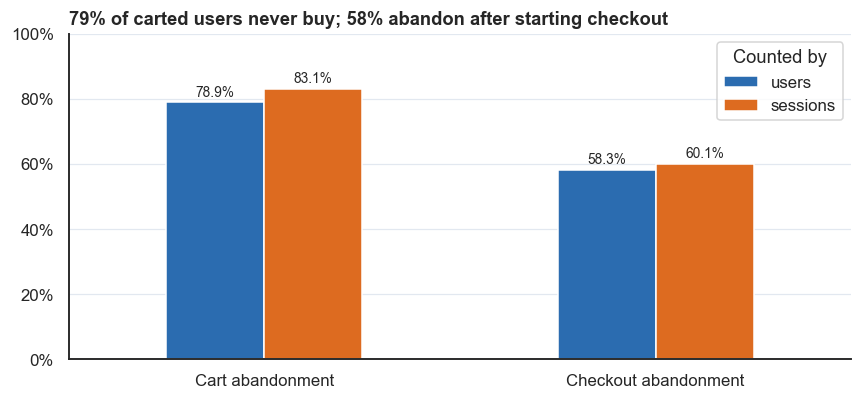

In [10]:
aband = load("04_funnel_abandonment.csv").set_index("level")
rates = pd.DataFrame({
    "Cart abandonment": aband.cart_abandonment_pct,
    "Checkout abandonment": aband.checkout_abandonment_pct,
}).loc[["users", "sessions"]]
ax = rates.T.plot.bar(figsize=(8, 3.8), color=[BLUE, ORANGE], rot=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
light_grid(ax, "y")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2, fontsize=9)
ax.set_ylim(0, 100)
ax.legend(title="Counted by")
ax.set_title("79% of carted users never buy; 58% abandon after starting checkout")
plt.tight_layout()
plt.show()

Cart abandonment is the share of users who added to cart and did not buy (78.9% of users, 83.1% of sessions). Checkout abandonment is the share of users who began checkout and did not buy (58.3% of users, 60.1% of sessions). Inside checkout, 40.8% of users who begin never add payment info, which is the biggest drop between checkout and purchase.

### Is the open funnel hiding something?

An open funnel counts a stage even when an earlier event is missing. Here that matters, because many users reach checkout and even purchase without ever firing an `add_to_cart` event.

In [11]:
open_checks = load("04_funnel_open_checks.csv").iloc[0]
strict = load("04_funnel_strict_check.csv").iloc[0]

compare = pd.DataFrame({
    "Stage": ["Product view", "Add to cart", "Begin checkout", "Add payment info", "Purchase"],
    "Open funnel (users)": main.users.iloc[1:].astype(int).to_list(),
    "Strict sequence (users)": [strict.product_view, strict.add_to_cart, strict.begin_checkout, strict.add_payment_info, strict.purchase],
}).astype({"Strict sequence (users)": int})
compare["Step conv. open %"] = (compare["Open funnel (users)"] / compare["Open funnel (users)"].shift(1) * 100).round(1)
compare["Step conv. strict %"] = (compare["Strict sequence (users)"] / compare["Strict sequence (users)"].shift(1) * 100).round(1)
compare.style.format({"Open funnel (users)": "{:,.0f}", "Strict sequence (users)": "{:,.0f}"}, na_rep="").hide(axis="index")

Stage,Open funnel (users),Strict sequence (users),Step conv. open %,Step conv. strict %
Product view,"61,252","61,252",,
Add to cart,"12,545","12,539",20.500000,20.500000
Begin checkout,"9,715","5,656",77.400000,45.100000
Add payment info,"5,751","3,654",59.200000,64.600000
Purchase,"4,055","2,643",70.500000,72.300000


**Caveat on the cart-to-checkout step.** In the open funnel, 77.4% of users who add to cart go on to begin checkout. In a strict sequence it is only **45.1%**. The difference comes from users who never fired `add_to_cart`: 4,058 of the 9,715 users who began checkout (41.8%) and 1,412 of the 4,055 purchasers (34.8%). Possible reasons are items added to the cart before 1 Nov, a quick "buy now" path, or the event not firing on some pages. The sample cannot tell which. The safe reading is that **add to cart is not a reliable gate**, so the strongest and most robust findings are the 79% loss between product view and cart and the 41% who begin checkout but never add payment info, while the true cart-to-checkout loss lies somewhere between 23% and 55%.